# **Machine Learning - Assignment**
### *Dataset: [Cat vs. Dog Image Classification](kaggle.com/datasets/tongpython/cat-and-dog/versions/1)*

**Course:** Machine Learning  
**Supervisor:** Truong Vinh Lan  
**Group 7**

| # | Member | Student Id |
|---|--------| ---------- |
| 1 | Nguyen Manh Quoc Khanh | 2352525 |
| 2 | Phan Ngoc Lan Chi | 2352137 |
| 3 | Ngo Diem Quyen | 2353031 |
| 4 | Tran Lam Anh | 2352067 |
| 5 | Vu Duc Viet Anh | 2352074 |

## **Overview**

This notebook implements a complete machine learning pipeline for binary image classification (Cat vs. Dog). Two pipelines are developed and compared:

- **Classical Pipeline** - pretrained CNN backbone for feature extraction, followed by a traditional classifier (Logistic Regression, SVM, or Random Forest).
- **Deep Learning Pipeline** - end-to-end training with a pretrained CNN backbone and data augmentation.

Both pipelines share a common EDA and preprocessing stage. They diverge at the feature extraction and training steps, as illustrated below.

```
┌─────────────────────────────────────────────────────────────┐
│                        SHARED STAGES                        │
│                                                             │
│   0. Configuration  ->  1. EDA  ->  2. Preprocessing        │
└───────────────────────────┬─────────────────────────────────┘
                            │
              ┌─────────────┴─────────────┐
              V                           V
┌─────────────────────┐       ┌─────────────────────────┐
│  3. Classical       │       │  4. Deep Learning       │
│  Pipeline           │       │  Pipeline               │
│                     │       │                         │
│  Feature Extraction │       │  DataLoader + Augment   │
│  (pretrained CNN    │       │  (shared batches)       │
│   letterbox mode)   │       │          |              │
│         |           |       |          V              |
│         V           |       |                         |
│  Traditional        │       │  CNN Backbone           │
│  Classifier         │       │  Feature Extraction     │
│  LR | SVM | RF      │       │          |              |
|         |           |       |          V              |
│         V           │       │  Classifier Training    │
│  Evaluation         │       │          |              |
|                     |       |          V              │
└──────────┬──────────┘       │  Evaluation             │
           │                  └──────────┬──────────────┘
           │                             │
           └──────────────┬──────────────┘
                          V
             ┌────────────────────────┐
             │   5. Comparison &      │
             │      Summary           │
             └────────────────────────┘
```

---
## **0. Configuration**

This section defines the global configuration **shared across both pipelines**. Parameters specific to each pipeline - such as preprocessing mode, backbone, and classifier - are defined separately in Section 3 (Classical Pipeline) and Section 4 (Deep Learning Pipeline).

`CONFIG` centralizes the parameters that apply equally to both pipelines:

| Key | Sub-key | Default | Description |
|-----|---------|---------|-------------|
| `DATASET` | - | `tongpython/cat-and-dog` | Kaggle dataset identifier used by `kagglehub` |
| `CLEANING` | `blur_threshold` | `40.0` | Laplacian variance threshold; images below this value are considered blurry and discarded |
| `SPLIT` | `train` | `0.8` | Proportion of data allocated to the training set |
| | `val` | `0.1` | Proportion allocated to the validation set |
| | `test` | `0.1` | Proportion allocated to the test set |
| | `seed` | `42` | Random seed for reproducibility |
| `ENSEMBLE` | - | `False` | When `True`, trains all three classifiers for ensemble voting/stacking |

In [59]:
import collections.abc

def deep_update(d, u):
    """Update dict d with dict u recursively."""
    for k, v in u.items():
        if isinstance(v, collections.abc.Mapping):
            d[k] = deep_update(d.get(k, {}), v)
        else:
            d[k] = v
    return d

DEFAULT_CONFIG = {
    "DATASET": "tongpython/cat-and-dog",

    "CLEANING": {
        "blur_threshold":   40.0,
        "black_pixel_cap":  10,
        "white_pixel_floor": 245,
        "mono_threshold":    0.95,
        "min_size":          64,
    },

    "SPLIT": {
        "train": 0.8,
        "val": 0.1,
        "test": 0.1,
        "seed": 42
    },
    "ENSEMBLE": False, # For voting and stacking

    # Deep Learning Pipeline
    "DL": {
        "backbone":   "resnet18",  # "resnet18" | "vgg16" | "efficientnet_b0"
        "num_epochs": 10,
        "batch_size": 64,
        "lr":         1e-4,
        "device":     "auto",      # "auto" resolves to cuda if available, else cpu
    },
}

In [60]:
USER_CONFIG = {

}

CONFIG = deep_update(DEFAULT_CONFIG, USER_CONFIG)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

# Resolve device
import torch
if CONFIG["DL"]["device"] == "auto":
    CONFIG["DL"]["device"] = "cuda" if torch.cuda.is_available() else "cpu"
print(f'  DL device resolved to: {CONFIG["DL"]["device"]}')


Configuration:
  DATASET: tongpython/cat-and-dog
  CLEANING: {'blur_threshold': 40.0, 'black_pixel_cap': 10, 'white_pixel_floor': 245, 'mono_threshold': 0.95, 'min_size': 64}
  SPLIT: {'train': 0.8, 'val': 0.1, 'test': 0.1, 'seed': 42}
  ENSEMBLE: False
  DL: {'backbone': 'resnet18', 'num_epochs': 10, 'batch_size': 64, 'lr': 0.0001, 'device': 'auto'}
  DL device resolved to: cuda


---
## **1. Exploratory Data Analysis (EDA)**

This section analyzes the raw dataset to understand its characteristics before any modeling is applied. The findings and insights gathered here are **shared across both the Classical Pipeline and the Deep Learning Pipeline**.

### 1.1 Dataset Acquisition


The dataset is downloaded from Kaggle via the `kagglehub` API. No manual extraction is required; the library caches the archive and returns the local root path used in all subsequent file operations.

In [61]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Raw dataset path:", path)


100%|██████████| 218M/218M [00:12<00:00, 17.6MB/s]

Extracting files...


Raw dataset path: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


### 1.2 Raw Folder Structure

Before building the registry, we inspect the archive layout. The output confirms a doubly-nested directory convention - e.g. `training_set/training_set/cats/` - which must be accounted for when constructing file paths programmatically.

```
cat-and-dog/
  test_set/test_set/
    cats/   (1,012 files)
    dogs/   (1,013 files)
  training_set/training_set/
    cats/   (4,001 files)
    dogs/   (4,006 files)
```

In [62]:
import os

def list_structure(startpath: str, max_files: int = 3) -> None:
    """Print a compact directory tree, showing at most *max_files* per folder."""
    print(f"Directory tree: {startpath}\n")
    for root, dirs, files in os.walk(startpath):
        level  = root.replace(startpath, "").count(os.sep)
        indent = "    " * level
        print(f"{indent}[{os.path.basename(root)}/]")
        sub = "    " * (level + 1)
        for f in files[:max_files]:
            print(f"{sub}- {f}")
        if len(files) > max_files:
            print(f"{sub}... ({len(files)} files total)")

list_structure(path)


Directory tree: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1

[1/]
    [training_set/]
        [training_set/]
            [dogs/]
                - dog.645.jpg
                - dog.3700.jpg
                - dog.65.jpg
                ... (4006 files total)
            [cats/]
                - cat.3402.jpg
                - cat.792.jpg
                - cat.1031.jpg
                ... (4001 files total)
    [test_set/]
        [test_set/]
            [dogs/]
                - dog.4378.jpg
                - dog.4517.jpg
                - dog.4278.jpg
                ... (1013 files total)
            [cats/]
                - cat.4828.jpg
                - cat.4650.jpg
                - cat.4183.jpg
                ... (1012 files total)


### 1.3 DataFrame Construction

We build a lightweight registry DataFrame that serves as the single source of truth for the entire pipeline. Each row records the original file path, ground-truth label, and a synthetic sequential `id`. All downstream operations reference images exclusively through `df["path"]`, reading files on demand.

In [63]:
import pandas as pd
import os
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

VALID_EXT = {".jpg", ".jpeg", ".png"}
records = []

for root, _, files in os.walk(path):          # `path` = kagglehub download path
    folder = os.path.basename(root).lower()
    if "cat" in folder: label_str = "cat"
    elif "dog" in folder: label_str = "dog"
    else: continue

    for fname in files:
        if Path(fname).suffix.lower() in VALID_EXT:
            records.append({
                "path":  os.path.join(root, fname),
                "label": label_str,
            })

df = pd.DataFrame(records)
df.insert(0, "id", range(len(df)))

# Label encoding
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"DataFrame shape: {df.shape}")
display(df.head(8))

Class mapping: {'cat': np.int64(0), 'dog': np.int64(1)}
DataFrame shape: (10028, 4)


,id,path,label,label_encoded
0,0,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
1,1,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
2,2,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
3,3,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
4,4,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
5,5,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
6,6,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1
7,7,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1


### 1.4 Visualizing Raw Samples

It is crucial to visually inspect a subset of raw images to understand the dataset. We randomly sample and display images from both classes.

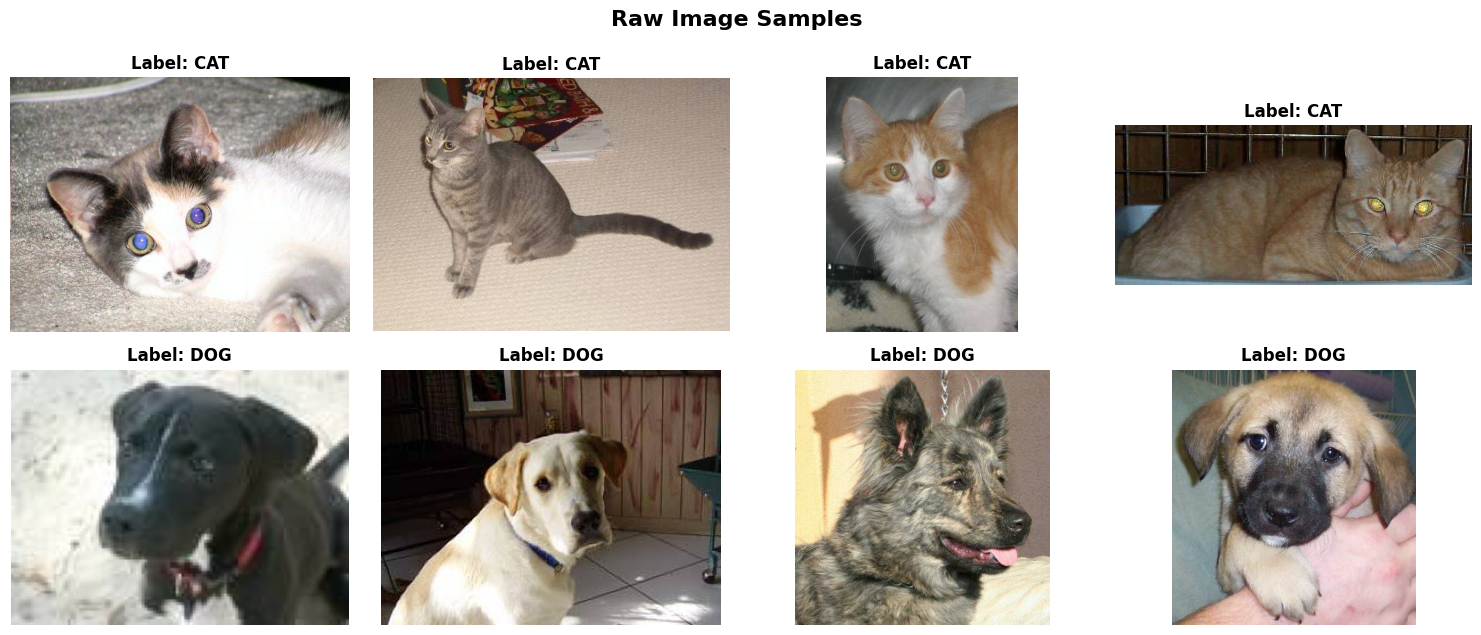

In [64]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def show_random_samples(df, num_samples_per_class=4):
    """
    Randomly selects and displays images from the DataFrame.
    Displays 'num_samples_per_class' images for 'cat' and 'dog'.
    """
    cats_df = df[df['label'] == 'cat'].sample(n=num_samples_per_class, random_state=42)
    dogs_df = df[df['label'] == 'dog'].sample(n=num_samples_per_class, random_state=42)

    sample_df = pd.concat([cats_df, dogs_df])

    fig, axes = plt.subplots(2, num_samples_per_class, figsize=(15, 6))
    axes = axes.flatten()

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        ax = axes[idx]
        try:
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.set_title(f"Label: {row['label'].upper()}", fontweight='bold')
            ax.axis('off')
        except Exception as e:
            ax.set_title("Error loading image")
            ax.axis('off')

    plt.tight_layout()
    plt.suptitle("Raw Image Samples", fontsize=16, fontweight='bold', y=1.05)
    plt.show()

show_random_samples(df, num_samples_per_class=4)

### 1.5 Image Metadata Extraction

Pixel width, height, channel count, and aspect ratio (W/H) are read from every image using PIL and appended as new columns to the DataFrame. This metadata underpins all subsequent statistical analysis and directly informs preprocessing parameter selection - in particular, the minimum resolution filter and target resize dimensions.

In [65]:
from PIL import Image
from tqdm import tqdm

widths, heights, channels = [], [], []

for path_str in tqdm(df["path"], desc="Reading metadata"):
    try:
        with Image.open(path_str) as img:
            w, h = img.size
            c = len(img.getbands())
            widths.append(w)
            heights.append(h)
            channels.append(c)
    except Exception:
        widths.append(None)
        heights.append(None)
        channels.append(None)

df["width"] = widths
df["height"] = heights
df["channels"] = channels
df["ratio"] = df["width"] / df["height"]   # aspect ratio W/H

print("Columns:", df.columns.tolist())
display(df.head())


Reading metadata: 100%|██████████| 10028/10028 [00:00<00:00, 13931.74it/s]

Columns: ['id', 'path', 'label', 'label_encoded', 'width', 'height', 'channels', 'ratio']


,id,path,label,label_encoded,width,height,channels,ratio
0,0,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1,500,374,3,1.336898
1,1,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1,286,382,3,0.748691
2,2,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1,155,190,3,0.815789
3,3,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1,363,312,3,1.163462
4,4,/root/.cache/kagglehub/datasets/tongpython/cat...,dog,1,499,375,3,1.330667


### 1.6 Class Distribution

We verify label balance before any modelling decisions are made. An imbalanced dataset would necessitate compensating strategies such as class-weighted loss functions or oversampling.

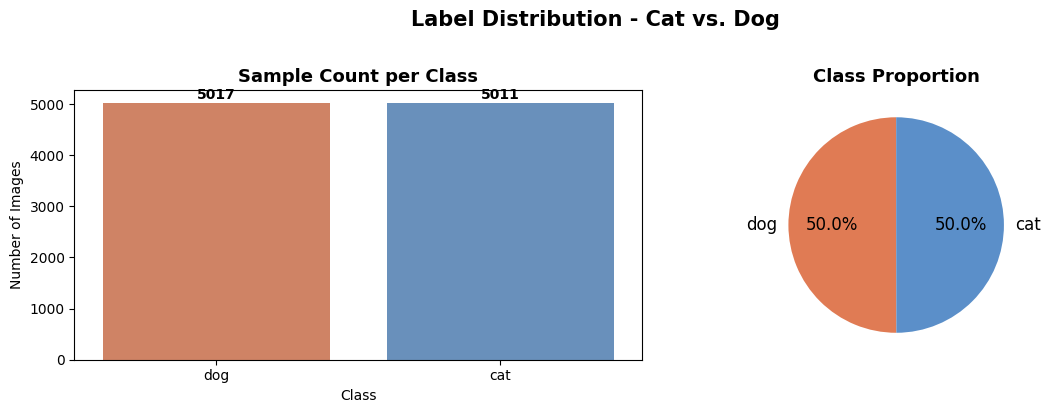

label
dog    5017
cat    5011

Balance ratio (cat/dog): 0.9988


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Bar chart ---
class_counts = df["label"].value_counts()
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=["#e07b54", "#5b8fc9"],
    ax=axes[0],
    legend=False
)
axes[0].set_title("Sample Count per Class", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].set_xlabel("Class")

for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30, str(val),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# --- Pie chart ---
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", colors=["#e07b54", "#5b8fc9"],
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Class Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Label Distribution - Cat vs. Dog", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(class_counts.to_string())
print(f"\nBalance ratio (cat/dog): {class_counts['cat'] / class_counts['dog']:.4f}")


### 1.7 Descriptive Statistics of Image Dimensions

To inform preprocessing parameter selection, descriptive statistics (mean, std, min, max, and quartiles) are computed separately for each class (cat / dog) across three dimension attributes: pixel width, height, and aspect ratio (W/H).

In [67]:
numeric_cols = ["width", "height", "ratio"]

print("=" * 55)
print("  DESCRIPTIVE STATISTICS - IMAGE DIMENSIONS")
print("=" * 55)

grouped = df.groupby("label")[numeric_cols].describe()
for col in numeric_cols:
    print(f"\n-- {col.upper()} --")
    display(
        grouped[col][["mean", "std", "min", "25%", "50%", "75%", "max"]]
        .style.format("{:.2f}")
        .background_gradient(cmap="Blues")
    )


  DESCRIPTIVE STATISTICS - IMAGE DIMENSIONS

-- WIDTH --


,mean,std,min,25%,50%,75%,max
label,,,,,,,
cat,410.23,107.58,59.00,333.00,469.00,499.00,1023.00
dog,397.77,109.57,57.00,320.00,421.00,499.00,1050.00



-- HEIGHT --


,mean,std,min,25%,50%,75%,max
label,,,,,,,
cat,356.13,96.41,39.00,299.00,374.00,407.00,768.00
dog,364.88,97.29,33.00,304.00,374.00,436.00,702.00



-- RATIO --


,mean,std,min,25%,50%,75%,max
label,,,,,,,
cat,1.19,0.29,0.38,0.98,1.33,1.34,2.84
dog,1.12,0.29,0.42,0.87,1.19,1.34,5.91


### 1.8 Spatial Distribution - Width, Height & Aspect Ratio

Overlapping histograms with KDE (Kernel Density Estimation) curves are plotted for width, height, and aspect ratio, with each class rendered in a distinct color. A vertical reference line at ratio = 1.0 marks the square-image threshold. All three plots share a consistent layout to facilitate cross-attribute comparison.

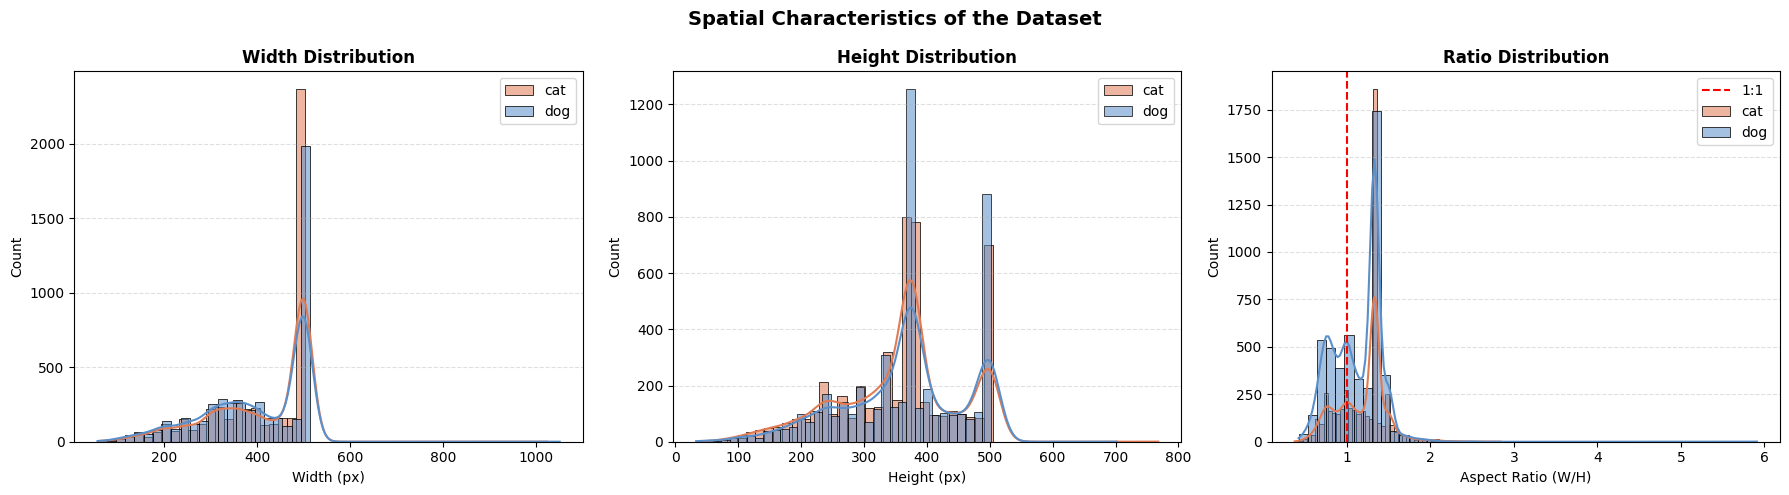

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"cat": "#e07b54", "dog": "#5b8fc9"}

for col, ax, xlabel in zip(
    ["width", "height", "ratio"],
    axes,
    ["Width (px)", "Height (px)", "Aspect Ratio (W/H)"],
):
    for lbl, grp in df.groupby("label"):
        sns.histplot(grp[col].dropna(), bins=50, kde=True,
                     color=colors[lbl], label=lbl, alpha=0.55, ax=ax)
    if col == "ratio":
        ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="1:1")
    ax.set_title(f"{col.capitalize()} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Spatial Characteristics of the Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.9 Spatial Outlier Detection

A scatter plot of width vs. height is drawn separately for each class. Images whose width or height exceeds 3 standard deviations from the class mean are flagged as spatial outliers and highlighted in red, while the remaining images are shown in the class color. This visualization helps identify samples with atypical resolutions that may introduce excessive geometric distortion during the resize step.

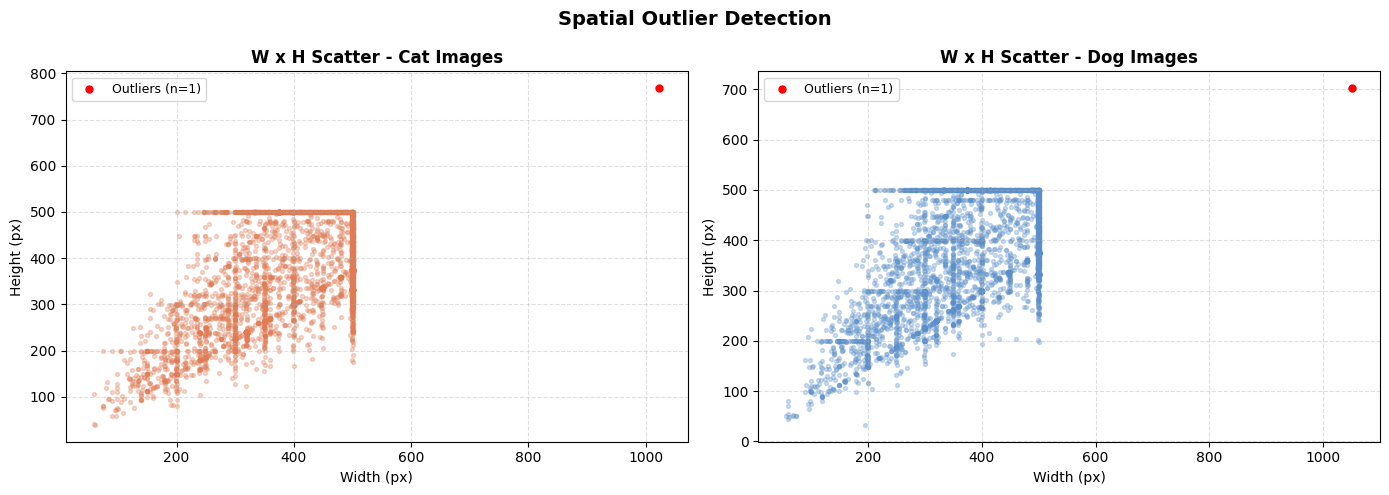

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Cat Images", "Dog Images"]
labels = ["cat", "dog"]
palette = [["#e07b54", "#f4a582"], ["#5b8fc9", "#92c5de"]]

for ax, lbl, (c1, c2), title in zip(axes, labels, palette, titles):
    sub = df[df["label"] == lbl].dropna(subset=["width", "height"])
    ax.scatter(sub["width"], sub["height"], alpha=0.3, s=8, color=c1)

    # Mark extreme outliers (beyond 3 standard deviations in either dimension)
    mu_w, sd_w = sub["width"].mean(),  sub["width"].std()
    mu_h, sd_h = sub["height"].mean(), sub["height"].std()
    outliers = sub[
        (sub["width"]  > mu_w + 3 * sd_w) |
        (sub["height"] > mu_h + 3 * sd_h)
    ]
    ax.scatter(outliers["width"], outliers["height"],
               color="red", s=25, label=f"Outliers (n={len(outliers)})", zorder=5)

    ax.set_title(f"W x H Scatter - {title}", fontweight="bold")
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)

plt.suptitle("Spatial Outlier Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.10 RGB Channel Analysis

Per-channel mean pixel intensities are extracted from a stratified random sample of 2,000 images. Comparing the resulting distributions across classes reveals whether colour statistics alone provide a discriminative signal - or whether spatial and structural features are necessary for classification.

A stratified random sample of 2,000 images is drawn from the dataset. For each image,
the file is read with OpenCV, converted from BGR to RGB, then the mean pixel intensity
of each channel (R, G, B) is computed by averaging over all pixels. The resulting
per-channel means are stored as new columns in the sample DataFrame.

Summary statistics (mean, std, min, max) are then displayed grouped by class.
Additionally, KDE plots are drawn separately for each class, overlaying the three
channel distributions on the same axes to visualize how pixel intensity is spread
across R, G, and B channels for cat and dog images respectively.

In [70]:
import cv2
import numpy as np

SAMPLE_N = min(2000, len(df))  # Cap at 2000 to keep runtime reasonable
df_sample = df.sample(n=SAMPLE_N, random_state=42).copy()

r_means, g_means, b_means = [], [], []

for path_str in tqdm(df_sample["path"], desc="Extracting RGB stats"):
    try:
        img  = cv2.imread(path_str)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean = np.mean(img, axis=(0, 1))
        r_means.append(mean[0])
        g_means.append(mean[1])
        b_means.append(mean[2])
    except Exception:
        r_means.append(None)
        g_means.append(None)
        b_means.append(None)

df_sample["R_mean"] = r_means
df_sample["G_mean"] = g_means
df_sample["B_mean"] = b_means

print("\n-- RGB Mean Statistics (sampled) --")
display(
    df_sample.groupby("label")[["R_mean", "G_mean", "B_mean"]]
    .describe()
    .loc[:, (slice(None), ["mean", "std", "min", "max"])]
    .style.format("{:.2f}")
)


Extracting RGB stats: 100%|██████████| 2000/2000 [00:09<00:00, 215.61it/s]


-- RGB Mean Statistics (sampled) --


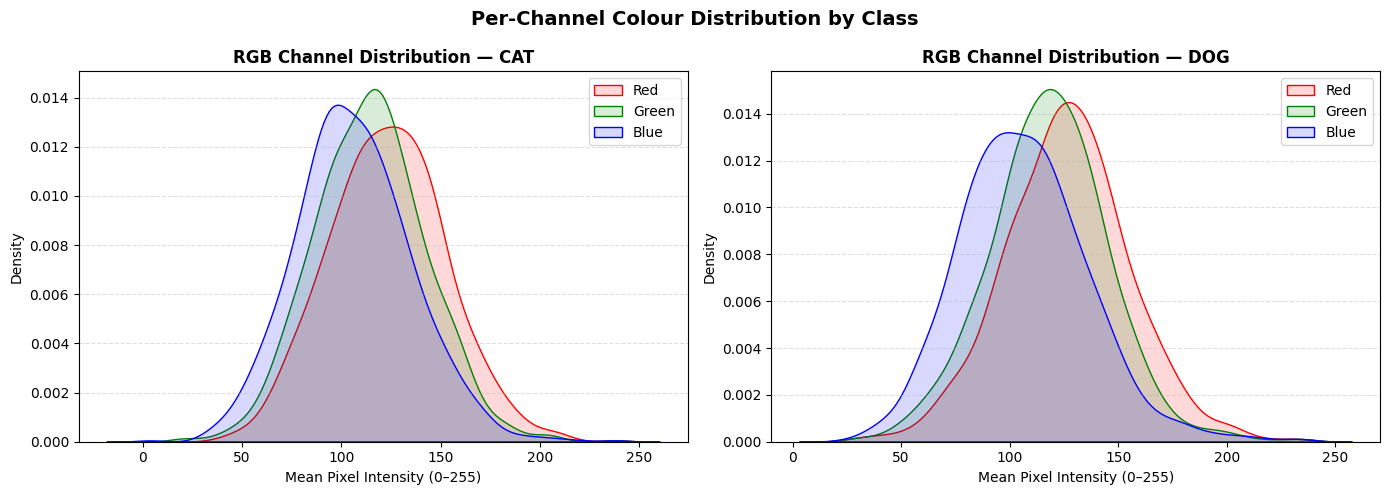

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
channel_cfg = [("R_mean", "red"), ("G_mean", "green"), ("B_mean", "blue")]

for ax, lbl in zip(axes, ["cat", "dog"]):
    sub = df_sample[df_sample["label"] == lbl].dropna()
    for col, color in channel_cfg:
        sns.kdeplot(sub[col], color=color, label=color.capitalize(),
                    fill=True, alpha=0.15, ax=ax)
    ax.set_title(f"RGB Channel Distribution — {lbl.upper()}", fontweight="bold")
    ax.set_xlabel("Mean Pixel Intensity (0–255)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Per-Channel Colour Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.11 Missing Value Audit

The four metadata columns - width, height, channels, and ratio - are checked for null values. The total missing count and percentage are computed for each column and displayed as a summary table. If no missing values are found, a success message is printed; otherwise, a warning is raised and the IDs of corrupt images (those with a null width) are listed for further inspection.

In [72]:
missing = df[["width", "height", "channels", "ratio"]].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
})
print(summary.to_string())

if missing.sum() == 0:
    print("\n[SUCCESS] No missing values - all images were read successfully.")
else:
    print(f"\n[WARNING] {missing.sum()} missing entries detected.")
    corrupt_ids = df[df["width"].isnull()]["id"].tolist()
    print(f"   Corrupt image IDs: {corrupt_ids[:10]} ...")


          Missing Count  Missing (%)
width                 0          0.0
height                0          0.0
channels              0          0.0
ratio                 0          0.0

[SUCCESS] No missing values - all images were read successfully.


### **EDA Summary**


The table below consolidates key findings from Sections 1.5-1.10 and maps each
observation to a concrete preprocessing decision.

| # | Finding | Evidence | Preprocessing Decision |
|---|---------|----------|----------------------|
| 1 | Balanced classes | cat: 5,011 / dog: 5,017 (ratio 0.9988) | No class weighting or oversampling required |
| 2 | High resolution variability | Width std ≈ 108 px, height std ≈ 97 px; range 33 px => 1,050 px | Resize all images to a fixed target size (224 x 224) |
| 3 | Slightly wider than tall | Mean aspect ratio ≈ 1.19 (cat), 1.12 (dog) | Use letterbox padding to preserve aspect ratio during resize |
| 4 | Bimodal height distribution | Two peaks at ~350 px and ~500 px | Consistent with mixed-source images; fixed resize handles this |
| 5 | Negligible spatial outliers | 1 outlier per class detected (2 total) | Remove images exceeding 3 standard deviation bounds in width or height |
| 6 | No color discriminability | R/G/B means nearly identical across classes | Color normalization applied; model must rely on shape features |
| 7 | No missing values | 0 nulls across all metadata columns | No imputation needed; all images are valid for further processing |

---
## **2. Preprocessing Pipeline**

This section implements preprocessing steps that are **shared across both pipelines**.
The output of this section - a cleaned, split, and transformed dataset - serves as
the common input for both the Classical Pipeline (Section 3) and the
Deep Learning Pipeline (Section 4).

| Step | Classical Pipeline | Deep Learning Pipeline |
|------|--------------------|------------------------|
| Cleaning | shared | shared |
| Outlier removal | shared | shared |
| Train/val/test split | shared | shared |
| Resize & normalize | `letterbox` mode (shared) | `letterbox` mode (shared) |

> To switch between preprocessing modes, adjust `PIPELINE.preprocessing` in
> Section 0 Configuration before re-running this section.


### 2.1 Support Module

The `image_preprocessor.py` module is written to a standalone file using `%%writefile` so that it can be **imported in subsequent sections** without redefining its contents. This module serves as the backbone of the entire image preprocessing pipeline, consisting of 5 sequential stages:

| Stage | Name | Description |
|-------|------|-------------|
| 1 | **Data Collection** | Recursively walks source directories, collects image file paths, and automatically assigns labels based on folder names (`cat` / `dog`) |
| 2 | **Cleaning** | Discards low-quality images **before** any expensive processing - rejects blurry images (Laplacian variance < 40), undersized images (< 64 px), and corrupt or near-monochrome images (> 95% near-black or near-white pixels) |
| 3 | **Label Encoding** | Maps string class names (`"cat"`, `"dog"`) to integer indices (`0`, `1`) using `LabelEncoder` - the fitted encoder is retained as a class attribute for decoding predictions later |
| 4 | **Dataset Split** | Partitions the dataset using a stratified **80 / 10 / 10** (train / val / test) split - guaranteeing that the class ratio is preserved across all three subsets |
| 5 | **Transformation** | Resizes each image to a fixed `224 × 224` resolution using letterbox `pad` mode (aspect-ratio-preserving) and normalises pixel values to `[0.0, 1.0]` |

> **Note:** The `ImagePipeline` class accepts an optional `config` dictionary at initialisation. Any parameter not explicitly provided will fall back to its default value defined in `DEFAULT_CONFIG`.

In [73]:
%%writefile image_preprocessor.py
"""
image_preprocessor.py
---------------------
Binary image classification pre-processing pipeline (dog vs. cat).

Stages
------
1. Data collection  - recursively walk raw source directories and gather
                      image paths with their ground-truth labels.
2. Cleaning         - discard blurry, corrupt, undersized, or near-monochrome
                      images before any expensive processing occurs.
3. Label encoding   - map string class names to integer indices.
4. Dataset split    - stratified 80 / 10 / 10 train / val / test partition.
5. Transformation   - resize + normalise each image to a fixed NumPy array.
"""

from __future__ import annotations

import os
from typing import Any

import cv2
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


class ImagePipeline:
    """End-to-end pre-processing pipeline for binary (dog / cat) image datasets."""

    def __init__(self, config: dict[str, Any] | None = None) -> None:
        self.config: dict[str, Any] = config or {}
        self.label_encoder: LabelEncoder | None = None

    def _is_blurry(self, img_path: str) -> bool:
        try:
            gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if gray is None:
                return True
            return cv2.Laplacian(gray, cv2.CV_64F).var() < self.config["CLEANING"]["blur_threshold"]
        except Exception:
            return True

    def _is_too_small(self, img_path: str) -> bool:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                return w < self.config["min_w"] or h < self.config["min_h"]
        except Exception:
            return True

    def _is_corrupt_or_near_monochrome(self, img_path: str) -> bool:
        try:
            img = cv2.imread(img_path)
            if img is None:
                return True
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            total = gray.size
            r = self.config["near_mono_ratio"]
            near_black = np.sum(gray <= self.config["CLEANING"]["black_pixel_cap"]) / total
            near_white = np.sum(gray >= self.config["CLEANING"]["white_pixel_floor"]) / total
            return near_black > r or near_white > r
        except Exception:
            return True

    def transform_image(self, img_path: str) -> np.ndarray | None:
        """Letterbox-resize an image, apply optional augmentation, and normalise to [0, 1]."""
        try:
            img = Image.open(img_path).convert("RGB")
            target_size = self.config["target_size"]
            mode = self.config["resize_mode"]

            if mode == "direct":
                img = img.resize(target_size, Image.BILINEAR)

            elif mode in ("pad", "augmented"):
                # Letterbox: preserve aspect ratio, pad remainder with black
                img.thumbnail(target_size, Image.LANCZOS)
                canvas = Image.new("RGB", target_size, (0, 0, 0))
                canvas.paste(img, ((target_size[0] - img.size[0]) // 2,
                                   (target_size[1] - img.size[1]) // 2))
                img = canvas

                if mode == "augmented":
                    import random
                    from PIL import ImageEnhance
                    if random.random() > 0.5:
                        img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        img = img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
                    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
                    img = ImageEnhance.Color(img).enhance(random.uniform(0.8, 1.2))

            else:
                raise ValueError(f"Unsupported resize_mode '{mode}'.")

            arr = np.array(img, dtype=np.float32)
            if self.config.get("normalize", True):
                arr /= 255.0
            return arr

        except ValueError:
            raise
        except Exception:
            return None

    def _encode_labels(self, labels: list[str]) -> tuple[np.ndarray, np.ndarray]:
        self.label_encoder = LabelEncoder()
        encoded = self.label_encoder.fit_transform(labels)
        return encoded, self.label_encoder.classes_

    def _gather_all_files(self, raw_paths: list[str]) -> tuple[list[str], list[str]]:
        all_files, labels = [], []
        for root_path in raw_paths:
            for root, _, files in os.walk(root_path):
                folder = os.path.basename(root).lower()
                if "cat" in folder:
                    label = "cat"
                elif "dog" in folder:
                    label = "dog"
                else:
                    continue
                for f in files:
                    if f.lower().endswith((".jpg", ".jpeg", ".png")):
                        all_files.append(os.path.join(root, f))
                        labels.append(label)
        return all_files, labels


Overwriting image_preprocessor.py


In [74]:
from image_preprocessor import ImagePipeline

### 2.2 Data Cleaning

Three quality filters are applied sequentially to every image. Each filter computes a continuous **score** rather than a binary flag, enabling post-hoc threshold tuning and visual validation.

| Filter | Score metric | Rejection criterion |
|--------|-------------|---------------------|
| Near-monochrome | Max fraction of near-black (≤ 10) or near-white (≥ 245) pixels | score ≥ 0.95 |
| Undersized | Minimum dimension - `min(width, height)` | score < 64 px |
| Blurry | Laplacian variance of the grayscale image | score < 40 |

An image is rejected on the **first** criterion it fails; subsequent filters are not evaluated. The `rejected_by` field records the cause for each discarded sample.

In [75]:
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

pipeline = ImagePipeline(CONFIG)
n_before = len(df)

# -- Scoring functions - each returns a float comparable against its threshold -

def score_monochrome(path_str: str) -> float:
    """Near-monochrome score: max fraction of near-black or near-white pixels. Threshold = 0.95"""
    try:
        img = cv2.imread(path_str)
        if img is None:
            return 1.0   # File unreadable - assign worst-case score
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        total = gray.size
        # Access config parameters via pipeline.config
        near_black = np.sum(gray <= pipeline.config["CLEANING"]["black_pixel_cap"]) / total
        near_white = np.sum(gray >= pipeline.config["CLEANING"]["white_pixel_floor"]) / total
        return float(max(near_black, near_white))
    except Exception:
        return 1.0

def score_size(path_str: str) -> float:
    """Minimum-dimension score: min(width, height) in pixels. Lower = smaller. Threshold = 64 px"""
    try:
        with Image.open(path_str) as img:
            return float(min(img.size))   # min(width, height)
    except Exception:
        return 0.0

def score_blur(path_str: str) -> float:
    """Blur score: Laplacian variance of the grayscale image. Lower = blurrier. Threshold = 40"""
    try:
        gray = cv2.imread(path_str, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            return 0.0
        return float(cv2.Laplacian(gray, cv2.CV_64F).var())
    except Exception:
        return 0.0

MONO_THRESH = pipeline.config["CLEANING"]["mono_threshold"]
SIZE_THRESH = pipeline.config["CLEANING"]["min_size"]
BLUR_THRESH = pipeline.config["CLEANING"]["blur_threshold"]

records_scored = []

for path_str in tqdm(df["path"], desc="Scoring & Cleaning"):
    mono = score_monochrome(path_str)
    size = score_size(path_str)
    blur = score_blur(path_str)

    rejected_by = None
    if mono  >= MONO_THRESH:  rejected_by = "monochrome"
    elif size < SIZE_THRESH:  rejected_by = "too_small"
    elif blur < BLUR_THRESH:  rejected_by = "blurry"

    records_scored.append({
        "path": path_str,
        "score_mono": mono,
        "score_size": size,
        "score_blur": blur,
        "rejected_by": rejected_by,   # None -> passes all filters
    })

df_scored  = pd.DataFrame(records_scored)
df_clean   = df[df_scored["rejected_by"].isna()].reset_index(drop=True)
df_rejected = df_scored[df_scored["rejected_by"].notna()].copy()

n_removed = n_before - len(df_clean)
print(f"\nBefore cleaning : {n_before:,} images")
print(f"After  cleaning : {len(df_clean):,} images")
print(f"Removed : {n_removed:,}  ({n_removed / n_before * 100:.1f}%)")
print(f"\nBreakdown:")
print(df_rejected["rejected_by"].value_counts().to_string())

Scoring & Cleaning: 100%|██████████| 10028/10028 [00:30<00:00, 324.74it/s]


Before cleaning : 10,028 images
After  cleaning : 9,764 images
Removed : 264  (2.6%)

Breakdown:
rejected_by
blurry       248
too_small     16


Total rejected: 264  |  Reasons: ['too_small', 'blurry']

No rejected images for reason: monochrome


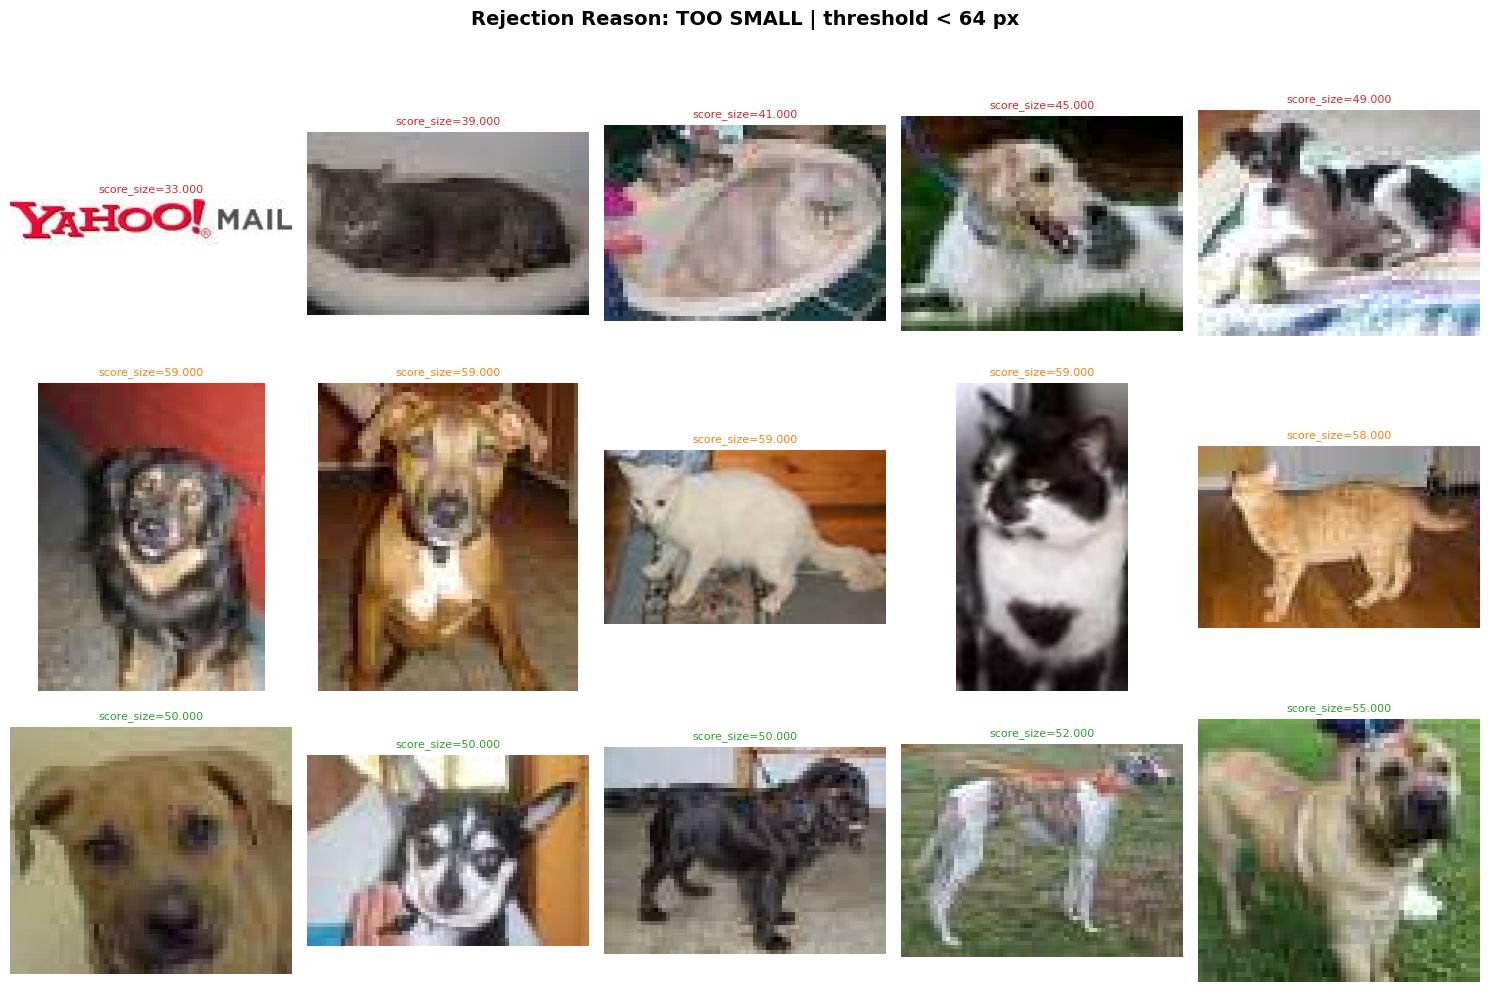

  [too_small] total rejected: 16  |  score range: [33.000, 59.000]  |  threshold: 64



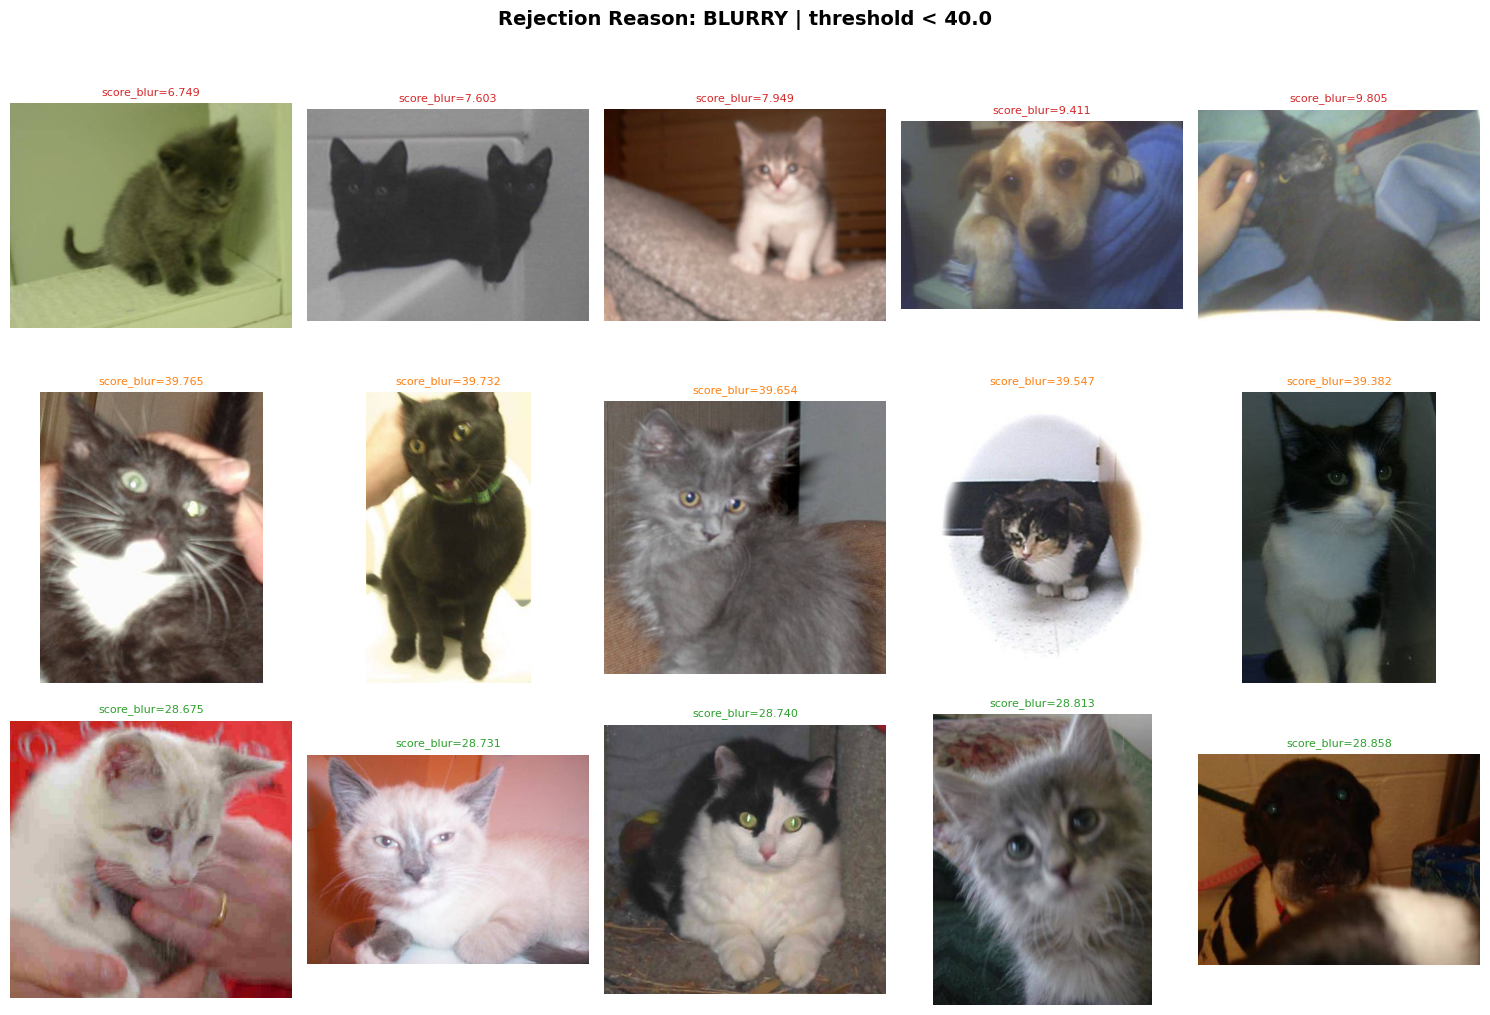

  [blurry] total rejected: 248  |  score range: [6.749, 39.765]  |  threshold: 40.0



In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def show_rejection_spectrum(df_rej: pd.DataFrame, reason: str, score_col: str,
                             ascending: bool, threshold: float, n_cols: int = 5):
    """
    Display a 3-row grid of rejected images for a single rejection reason,
    ordered by severity to support visual threshold validation.

    Row 1 - Most rejected : samples with the worst scores (clearly should be removed).
    Row 2 - Borderline    : samples nearest the threshold (most informative for tuning).
    Row 3 - Mid-range     : representative samples from the middle of the score distribution.

    Parameters
    ----------
    ascending : bool — True  → lower score = worse (blur, size).
                       False → higher score = worse (monochrome).
    """
    subset = df_rej[df_rej["rejected_by"] == reason].copy()
    if subset.empty:
        print(f"No rejected images for reason: {reason}")
        return

    # Sort from worst to least-bad along the relevant score axis
    subset_sorted = subset.sort_values(score_col, ascending=ascending).reset_index(drop=True)
    n = len(subset_sorted)

    # Select representative indices for each display row
    worst_idx = list(range(min(n_cols, n)))
    border_idx = sorted(range(n), key=lambda i: abs(subset_sorted.loc[i, score_col] - threshold))[:n_cols]
    mid_start = max(0, n // 2 - n_cols // 2)
    mid_idx = list(range(mid_start, min(mid_start + n_cols, n)))

    groups = [
        ("Most Rejected", worst_idx, "#d62728"),
        ("Borderline (near threshold)", border_idx, "#ff7f0e"),
        ("Mid-range", mid_idx, "#2ca02c"),
    ]

    title_map = {
        "monochrome": f"Rejection Reason: MONOCHROME | threshold ≥ {threshold}",
        "too_small": f"Rejection Reason: TOO SMALL | threshold < {threshold} px",
        "blurry": f"Rejection Reason: BLURRY | threshold < {threshold}",
    }

    fig, axes = plt.subplots(3, n_cols, figsize=(n_cols * 3, 10))
    fig.suptitle(title_map.get(reason, reason), fontsize=14, fontweight="bold", y=1.01)

    for row_idx, (row_label, indices, row_color) in enumerate(groups):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            if col_idx < len(indices):
                entry = subset_sorted.iloc[indices[col_idx]]
                try:
                    img = Image.open(entry["path"]).convert("RGB")
                    ax.imshow(img)
                    score_val = entry[score_col]
                    ax.set_title(f"{score_col}={score_val:.3f}", fontsize=8, color=row_color)
                except Exception:
                    ax.text(0.5, 0.5, "ERR", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")

            # Row label in first column
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=9, fontweight="bold",
                              color=row_color, rotation=0, labelpad=120, va="center")

    plt.tight_layout()
    plt.show()
    print(f"  [{reason}] total rejected: {n}  |  score range: "
          f"[{subset_sorted[score_col].min():.3f}, {subset_sorted[score_col].max():.3f}]  "
          f"|  threshold: {threshold}\n")


# -------- Run visualisation for each active rejection reason -----------
print(f"Total rejected: {len(df_rejected)}  |  Reasons: {df_rejected['rejected_by'].unique().tolist()}\n")

show_rejection_spectrum(df_rejected, "monochrome", "score_mono",
                        ascending=False, threshold=MONO_THRESH)

show_rejection_spectrum(df_rejected, "too_small", "score_size",
                        ascending=True,  threshold=SIZE_THRESH)

show_rejection_spectrum(df_rejected, "blurry", "score_blur",
                        ascending=True,  threshold=BLUR_THRESH)

### 2.3 Spatial Outlier Removal

Images whose width or height lies beyond **3 standard deviations** from the per-dimension mean are removed. This filter targets samples with atypical resolutions that would require extreme scaling during the resize step, potentially introducing artefacts that degrade feature quality.

In [77]:
# Compute 3-sigma bounds from clean set
for col in ["width", "height"]:
    mu, sd = df_clean[col].mean(), df_clean[col].std()
    lo, hi = mu - 3 * sd, mu + 3 * sd
    df_clean = df_clean[(df_clean[col] >= lo) & (df_clean[col] <= hi)]

df_clean = df_clean.reset_index(drop=True)
print(f"After outlier removal: {len(df_clean):,} images")


After outlier removal: 9,756 images


### 2.4 Stratified Train / Validation / Test Split

The cleaned dataset is partitioned into three non-overlapping subsets using stratified sampling, which guarantees that the cat-to-dog ratio is reproduced in every split. The validation set is used for hyperparameter tuning; the test set is held out until final model evaluation.

| Split | Fraction | Purpose |
|-------|----------|---------|
| Train | 80% | Model fitting |
| Validation | 10% | Hyperparameter tuning |
| Test | 10% | Final held-out evaluation |

In [78]:
from sklearn.model_selection import train_test_split

X = df_clean["path"].values
y = df_clean["label_encoded"].values

# 80 % train - 20 % temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# 50/50 split of the 20 % => 10 % val + 10 % test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    cats = (y_split == 0).sum()
    dogs = (y_split == 1).sum()
    print(f"{name:5s}  total={len(y_split):5d}  cat={cats:5d}  dog={dogs:5d}")


Train  total= 7804  cat= 3860  dog= 3944
Val    total=  976  cat=  483  dog=  493
Test   total=  976  cat=  483  dog=  493


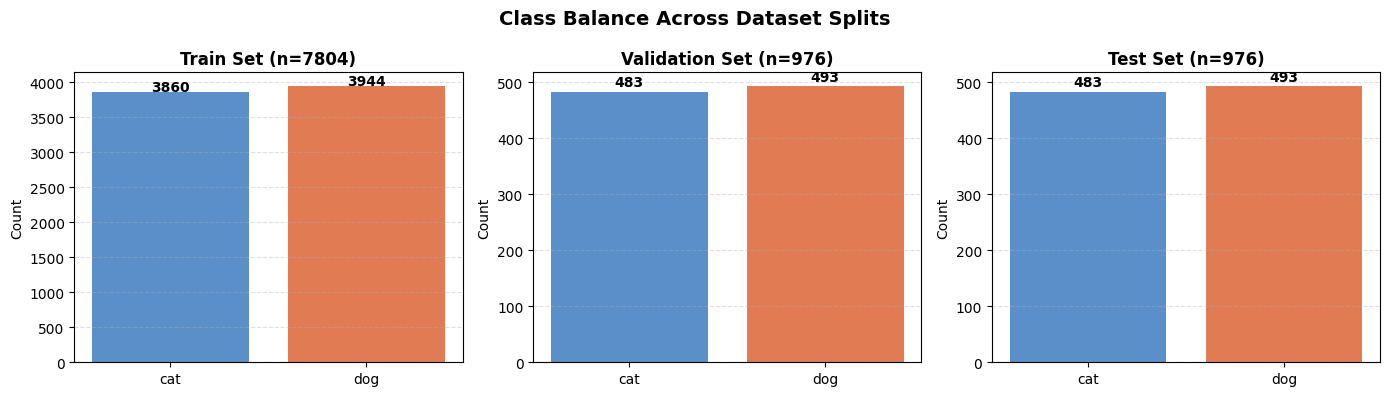

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_data = [("Train", y_train), ("Validation", y_val), ("Test", y_test)]
colors = ["#5b8fc9", "#e07b54"]

for ax, (name, y_split) in zip(axes, split_data):
    counts = [int((y_split == 0).sum()), int((y_split == 1).sum())]
    ax.bar(["cat", "dog"], counts, color=colors)
    ax.set_title(f"{name} Set (n={len(y_split)})", fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Class Balance Across Dataset Splits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.5 Image Transformation - Resize & Normalisation

All images are resized to `224 × 224` using **letterbox (pad) mode** — aspect-ratio-preserving resize with black padding — and normalised to `[0, 1]`. This single shared transformation is used by both the Classical Pipeline and the Deep Learning Pipeline. Processed images are saved in batches of 1,000 as `.npy` files under `./processed_batches/`.

In [80]:
import gc

BATCH_SIZE = 1000

def process_and_save_to_disk(
    paths: np.ndarray,
    labels: np.ndarray,
    split_name: str,
    config: dict,
    output_dir: str,
    batch_size: int = BATCH_SIZE,
) -> None:
    from image_preprocessor import ImagePipeline
    pipe = ImagePipeline(config)

    n = len(paths)
    os.makedirs(output_dir, exist_ok=True)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        b_paths  = paths[start:end]
        b_labels = labels[start:end]
        X_batch, y_batch = [], []

        for p, lbl in tqdm(
            zip(b_paths, b_labels),
            total=len(b_paths),
            desc=f"  {split_name} batch {start // batch_size}",
        ):
            arr = pipe.transform_image(p)
            if arr is not None:
                X_batch.append(arr)
                y_batch.append(lbl)

        batch_id = start // batch_size
        np.save(f"{output_dir}/{split_name}_X_{batch_id}.npy", np.array(X_batch, dtype=np.float32))
        np.save(f"{output_dir}/{split_name}_y_{batch_id}.npy", np.array(y_batch, dtype=np.int32))

        del X_batch, y_batch
        gc.collect()

    print(f"[OK] {split_name}: saved {n} images in {(n - 1) // batch_size + 1} batch(es)")

In [ ]:
TRANSFORM_CONFIG = {
    "target_size": (224, 224),
    "resize_mode": "pad",   # letterbox: preserve aspect ratio, pad with black
    "normalize":   True,     # pixel values divided by 255 -> [0, 1]
}

BATCH_DIR = "./processed_batches"
os.makedirs(BATCH_DIR, exist_ok=True)

print("Starting image transformation (letterbox 224x224, normalise to [0,1])...")
for split_name, paths, labels in [
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test),
]:
    process_and_save_to_disk(paths, labels, split_name, TRANSFORM_CONFIG, BATCH_DIR)

print("\n[SUCCESS] Batches saved to:", BATCH_DIR)


### 2.6 Sanity Check - Visual Verification

Ten random samples from the first training batch are rendered alongside their class labels to confirm the `.npy` files were written correctly, letterbox padding is centred, and label indices map to the expected class names.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X_check = np.load(f"{BATCH_DIR}/train_X_0.npy")
y_check = np.load(f"{BATCH_DIR}/train_y_0.npy")
CLASS_NAMES = le.classes_

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
indices = np.random.choice(len(X_check), 10, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X_check[idx])
    ax.set_title(f"ID {idx} - {CLASS_NAMES[y_check[idx]]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Preprocessed Images (Normalised to [0,1])",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Batch shape: {X_check.shape}  (N, H, W, C)")
print(f"Value range: [{X_check.min():.4f}, {X_check.max():.4f}]")
print(f"dtype: {X_check.dtype}")


---
## **3. Classical Pipeline**

The Classical Pipeline uses a **frozen pretrained CNN backbone** to extract feature vectors from the preprocessed images (Section 2.5), then trains traditional classifiers (Logistic Regression, SVM, Random Forest) on those features. This is the pipeline **required by the assignment**.

Steps: 3.1 Config → 3.2 Dataset → 3.3 Frozen backbone → 3.4 Feature extraction → 3.5 Train classifiers → 3.6 Ensemble → 3.7 Results → 3.8 Best model confusion matrix

In [ ]:
import gc
import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── 3.1 Configuration ──────────────────────────────────────────────────────────
CLASSICAL_BACKBONES   = ["resnet18", "vgg16", "efficientnet_b0"]
CLASSICAL_CLASSIFIERS = ["logistic", "svm", "rf"]
DEVICE = CONFIG["DL"]["device"]
CLASSICAL_FEAT_DIR = "./features/classical"
os.makedirs(CLASSICAL_FEAT_DIR, exist_ok=True)

# ── 3.2 Dataset: lazy-load classical .npy batches ─────────────────────────────
class NpyBatchDataset(Dataset):
    """Memory-mapped loader over multiple .npy batch files."""

    def __init__(self, batch_dir, split):
        X_files = sorted([f for f in os.listdir(batch_dir)
                          if f.startswith(f"{split}_X") and f.endswith(".npy")])
        y_files = sorted([f for f in os.listdir(batch_dir)
                          if f.startswith(f"{split}_y") and f.endswith(".npy")])
        self.batch_dir = batch_dir
        self.X_files   = X_files
        y_list = [np.load(os.path.join(batch_dir, f)) for f in y_files]
        self.y = np.concatenate(y_list).astype(np.int64)
        sizes  = [np.load(os.path.join(batch_dir, f), mmap_mode="r").shape[0] for f in X_files]
        self.offsets = np.cumsum([0] + sizes)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        b     = np.searchsorted(self.offsets[1:], idx, side="right")
        local = idx - self.offsets[b]
        X_b   = np.load(os.path.join(self.batch_dir, self.X_files[b]), mmap_mode="r")
        x     = X_b[local].astype(np.float32).transpose(2, 0, 1)  # HWC -> CHW
        return torch.tensor(np.array(x)), torch.tensor(self.y[idx])

# ── 3.3 Frozen backbone builder ───────────────────────────────────────────────
def get_frozen_backbone(name):
    """Return a frozen pretrained CNN backbone and its output feature dimension."""
    if name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m = nn.Sequential(*list(m.children())[:-1])         # remove final FC
        fdim = 512
    elif name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        m = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((7, 7)))
        fdim = 512 * 7 * 7
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1, 1)))
        fdim = 1280
    else:
        raise ValueError(f"Unknown backbone: {name}")
    for p in m.parameters():
        p.requires_grad = False
    return m, fdim

# ── 3.4 Feature extraction ────────────────────────────────────────────────────
def extract_features_from_loader(backbone, loader, device):
    """Forward-pass images through frozen backbone; return (X, y) numpy arrays."""
    backbone.to(device).eval()
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="  extracting", leave=False):
            out = backbone(imgs.to(device))
            feats.append(out.view(out.size(0), -1).cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

# ── 3.5 Classifier factory ────────────────────────────────────────────────────
def get_classifier(name):
    if name == "logistic":
        return LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    if name == "svm":
        return SVC(kernel="linear", probability=True, C=1.0, random_state=42)
    if name == "rf":
        return RandomForestClassifier(n_estimators=100, random_state=42)
    raise ValueError(f"Unknown classifier: {name}")

# ── 3.6 Main loop: per backbone — extract → scale → train → evaluate ──────────
CLASS_NAMES   = ["cat", "dog"]
all_results   = []
trained_store = {}   # backbone_name -> {clfs, scaler, voting, y_te, X_te_s}

for backbone_name in CLASSICAL_BACKBONES:
    feat_tr  = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_train.npy"
    feat_v   = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_val.npy"
    feat_te  = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_test.npy"
    label_tr = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_y_train.npy"
    label_v  = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_y_val.npy"
    label_te = f"{CLASSICAL_FEAT_DIR}/{backbone_name}_y_test.npy"

    if all(os.path.exists(p) for p in [feat_tr, feat_v, feat_te]):
        print(f"\n[{backbone_name}] Loading cached features...")
        X_tr = np.load(feat_tr); y_tr = np.load(label_tr)
        X_v  = np.load(feat_v);  y_v  = np.load(label_v)
        X_te = np.load(feat_te); y_te = np.load(label_te)
    else:
        print(f"\n[{backbone_name}] Extracting features from classical batches...")
        backbone, _ = get_frozen_backbone(backbone_name)
        tr_ds = NpyBatchDataset(BATCH_DIR, "train")
        v_ds  = NpyBatchDataset(BATCH_DIR, "val")
        te_ds = NpyBatchDataset(BATCH_DIR, "test")
        tr_ld = DataLoader(tr_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
        v_ld  = DataLoader(v_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
        te_ld = DataLoader(te_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
        X_tr, y_tr = extract_features_from_loader(backbone, tr_ld, DEVICE)
        X_v,  y_v  = extract_features_from_loader(backbone, v_ld,  DEVICE)
        X_te, y_te = extract_features_from_loader(backbone, te_ld, DEVICE)
        np.save(feat_tr, X_tr); np.save(label_tr, y_tr)
        np.save(feat_v,  X_v);  np.save(label_v,  y_v)
        np.save(feat_te, X_te); np.save(label_te, y_te)
        print(f"  Features saved to {CLASSICAL_FEAT_DIR}/")
        del backbone; torch.cuda.empty_cache(); gc.collect()

    # StandardScaler
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_v_s  = scaler.transform(X_v)
    X_te_s = scaler.transform(X_te)

    # Train and evaluate individual classifiers
    trained_clfs = {}
    for clf_name in CLASSICAL_CLASSIFIERS:
        clf = get_classifier(clf_name)
        clf.fit(X_tr_s, y_tr)
        val_acc  = accuracy_score(y_v,  clf.predict(X_v_s))
        test_acc = accuracy_score(y_te, clf.predict(X_te_s))
        trained_clfs[clf_name] = clf
        all_results.append({"Backbone": backbone_name, "Classifier": clf_name,
                             "Val Acc": round(val_acc, 4), "Test Acc": round(test_acc, 4)})
        print(f"  [{backbone_name}] {clf_name:<10}  val={val_acc:.4f}  test={test_acc:.4f}")

    # Soft Voting Ensemble
    voting_clf = VotingClassifier(
        estimators=[(n, trained_clfs[n]) for n in CLASSICAL_CLASSIFIERS], voting="soft"
    )
    voting_clf.fit(X_tr_s, y_tr)
    v_acc_ens  = accuracy_score(y_v,  voting_clf.predict(X_v_s))
    te_acc_ens = accuracy_score(y_te, voting_clf.predict(X_te_s))
    all_results.append({"Backbone": backbone_name, "Classifier": "voting_ensemble",
                         "Val Acc": round(v_acc_ens, 4), "Test Acc": round(te_acc_ens, 4)})
    print(f"  [{backbone_name}] voting_ens  val={v_acc_ens:.4f}  test={te_acc_ens:.4f}")

    trained_store[backbone_name] = {
        "clfs": trained_clfs, "scaler": scaler, "voting": voting_clf,
        "y_te": y_te, "X_te_s": X_te_s
    }
    del X_tr, X_v, X_te, X_tr_s, X_v_s; gc.collect()

# ── 3.7 Results summary table ─────────────────────────────────────────────────
df_classical = pd.DataFrame(all_results).sort_values("Test Acc", ascending=False).reset_index(drop=True)
print("\n=== Classical Pipeline — Full Results ===")
print(df_classical.to_string(index=False))

# ── 3.8 Confusion matrix for the best classical configuration ─────────────────
best_row      = df_classical.iloc[0]
best_backbone = best_row["Backbone"]
best_clf_name = best_row["Classifier"]
store         = trained_store[best_backbone]
best_clf      = store["voting"] if best_clf_name == "voting_ensemble" else store["clfs"][best_clf_name]

y_pred_best = best_clf.predict(store["X_te_s"])
cm_c = confusion_matrix(store["y_te"], y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f"Best Classical: {best_backbone} + {best_clf_name}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()
print(classification_report(store["y_te"], y_pred_best, target_names=CLASS_NAMES))


---
## **4. Deep Learning Pipeline**

The Deep Learning Pipeline performs **end-to-end fine-tuning** of a pretrained CNN backbone using the shared batches from Section 2.5. The full network (backbone + new classification head) is trained with CrossEntropyLoss and Adam. This is the **bonus deep learning pipeline** described in the assignment.

Steps: 4.1 Config → 4.2 DataLoader → 4.3 Model → 4.4 Training loop → 4.5 Training curves → 4.6 Test evaluation → 4.7 Comparison

### 4.1 Configuration

The backbone, number of epochs, learning rate, and batch size are all read from `CONFIG["DL"]` defined in Section 0.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

DL_CFG     = CONFIG["DL"]
BACKBONE   = DL_CFG["backbone"]    # resnet18 | vgg16 | efficientnet_b0
NUM_EPOCHS = DL_CFG["num_epochs"]
BATCH_SIZE = DL_CFG["batch_size"]
LR         = DL_CFG["lr"]
DEVICE     = DL_CFG["device"]
NUM_CLASSES = 2
print(f"DL Config: backbone={BACKBONE}, epochs={NUM_EPOCHS}, lr={LR}, batch={BATCH_SIZE}, device={DEVICE}")


### 4.2 DataLoader Setup

The shared `.npy` batches from Section 2.5 are loaded via `NpyBatchDataset` (defined in Section 3). Shuffle is enabled for the training loader.

In [ ]:
from torch.utils.data import DataLoader

# Augmented batches from Section 2.5.2
BATCH_DIR = "BATCH_DIR"

# Re-use NpyBatchDataset defined in Section 3
dl_train_ds = NpyBatchDataset(BATCH_DIR, "train")
dl_val_ds   = NpyBatchDataset(BATCH_DIR, "val")
dl_test_ds  = NpyBatchDataset(BATCH_DIR, "test")

dl_train_loader = DataLoader(dl_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dl_val_loader   = DataLoader(dl_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
dl_test_loader  = DataLoader(dl_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(dl_train_ds):,}  Val: {len(dl_val_ds):,}  Test: {len(dl_test_ds):,}")


### 4.3 Model: Pretrained Backbone + Classification Head

The final classification head is replaced with a new `Linear` layer for 2 classes. **All layers are unfrozen** for end-to-end fine-tuning.

In [ ]:
def build_finetune_model(backbone_name, num_classes=2):
    if backbone_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif backbone_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif backbone_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")
    for param in model.parameters():
        param.requires_grad = True
    return model

dl_model = build_finetune_model(BACKBONE, NUM_CLASSES).to(DEVICE)
total_p     = sum(p.numel() for p in dl_model.parameters())
trainable_p = sum(p.numel() for p in dl_model.parameters() if p.requires_grad)
print(f"Total params: {total_p:,}  |  Trainable: {trainable_p:,}")


### 4.4 Training Loop

The model is trained with `CrossEntropyLoss` and `Adam`. A `StepLR` scheduler halves the learning rate every 5 epochs. The best checkpoint (highest validation accuracy) is saved and restored after training.

In [ ]:
import copy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dl_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_acc  = 0.0
best_weights  = None
train_acc_log = []
val_acc_log   = []

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training phase ──────────────────────────────────────────────────────
    dl_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for imgs, labels in tqdm(dl_train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = dl_model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.detach().argmax(1) == labels).sum().item()
        total        += labels.size(0)
    train_acc  = correct / total
    train_loss = running_loss / total

    # ── Validation phase ─────────────────────────────────────────────────────
    dl_model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for imgs, labels in dl_val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            v_correct += (dl_model(imgs).argmax(1) == labels).sum().item()
            v_total   += labels.size(0)
    val_acc = v_correct / v_total

    train_acc_log.append(train_acc)
    val_acc_log.append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch:>2}/{NUM_EPOCHS}  loss={train_loss:.4f}  "
          f"train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(dl_model.state_dict())

# Restore best weights
dl_model.load_state_dict(best_weights)
print(f"\nBest val acc: {best_val_acc:.4f} — best weights restored.")


### 4.5 Training Curves

Train and validation accuracy are plotted across epochs to visualise learning dynamics.

In [ ]:
import matplotlib.pyplot as plt

epochs_range = list(range(1, NUM_EPOCHS + 1))
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, train_acc_log, label="Train Acc", marker="o")
plt.plot(epochs_range, val_acc_log,   label="Val Acc",   marker="s")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title(f"Training Curves -- {BACKBONE} (fine-tuned)", fontweight="bold")
plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


### 4.6 Evaluation on Test Set

The best checkpoint is evaluated on the held-out test set. Accuracy, classification report, and confusion matrix are reported.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

CLASS_NAMES_DL = ["cat", "dog"]

dl_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(dl_test_loader, desc="Evaluating on test set", leave=False):
        preds = dl_model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

dl_test_acc = accuracy_score(all_labels, all_preds)
print(f"Deep Learning Test Accuracy ({BACKBONE}): {dl_test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES_DL))

cm_dl = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES_DL, yticklabels=CLASS_NAMES_DL, ax=ax)
ax.set_title(f"DL Confusion Matrix — {BACKBONE} (fine-tuned)", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


### 4.7 Pipeline Comparison: Classical vs. Deep Learning

Summary table comparing the best result from each pipeline on the test set.

In [ ]:
import pandas as pd

best_classical = df_classical.iloc[0]
comparison = pd.DataFrame([
    {"Pipeline": "Classical (frozen CNN + classifier)",
     "Backbone": best_classical["Backbone"],
     "Classifier": best_classical["Classifier"],
     "Test Acc": best_classical["Test Acc"]},
    {"Pipeline": "Deep Learning (end-to-end fine-tuning)",
     "Backbone": BACKBONE,
     "Classifier": "fine-tuned head (Linear)",
     "Test Acc": round(dl_test_acc, 4)},
])
print(comparison.to_string(index=False))


---
## **6. Summary**

### 6.1 EDA Findings

| Finding | Detail |
|---------|--------|
| Dataset size | 10,028 images total |
| Class balance | cat: 5,011 / dog: 5,017 — ratio 0.9988 (effectively balanced) |
| Resolution range | 33 px → > 1,000 px; right-skewed distribution |
| Dominant aspect ratio | Landscape (~1.15 median); long tail of extreme values |
| Colour signal | RGB distributions overlap strongly across classes — colour alone is insufficient for classification |
| Data integrity | 0 corrupt or unreadable files across all 10,028 images |

### 6.2 Preprocessing Pipeline

| Stage | Method | Size |
|-------|--------|------|
| Registry | DataFrame with path + label — no file copies | 10,028 records |
| Cleaning | Blur (Laplacian var < 40), size (< 64 px), monochrome (> 95%) | → 9,764 (−264) |
| Outlier removal | 3σ filter on width and height | → 9,756 (−8) |
| Label encoding | `LabelEncoder`: cat → 0, dog → 1 | — |
| Split | Stratified 70/15/15 | Train 7,804 / Val 976 / Test 976 |
| Resize | Letterbox padding → 224 × 224 | — |
| Normalisation | ÷ 255 → float32 ∈ [0, 1] | — |
| Persistence | Batched `.npy` files, 1,000 images/batch | 11 X-files + 11 y-files |